<a href="https://colab.research.google.com/github/alv140404/V-Anh/blob/main/PDDS_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip pdds.zip
%ls

Archive:  pdds.zip
  inflating: pdds/__init__.py        
  inflating: pdds/potentials.py      
  inflating: pdds/vi.py              
  inflating: pdds/resampling.py      
  inflating: pdds/sde.py             
  inflating: pdds/utils/cfg.py       
  inflating: pdds/ml_tools/__init__.py  
  inflating: pdds/utils/jax.py       
  inflating: pdds/utils/shaping.py   
  inflating: pdds/ml_tools/state.py  
  inflating: pdds/nn_models/__init__.py  
  inflating: pdds/__pycache__/smc_loops.cpython-311.pyc  
  inflating: pdds/utils/cp_utils.py  
  inflating: pdds/__pycache__/smc_problem.cpython-311.pyc  
  inflating: pdds/utils/__init__.py  
  inflating: pdds/utils/step_size_schedules.py  
  inflating: pdds/nn_models/mlp.py   
  inflating: pdds/smc_problem.py     
  inflating: pdds/run_sde_train.py   
  inflating: pdds/plotting.py        
  inflating: pdds/ml_tools/asynclib.py  
  inflating: pdds/distributions.py   
  inflating: pdds/utils/haiku.py     
  inflating: pdds/utils/lr_schedules.py  
  

# Particle Denoising Diffusion Sampler (PDDS)

This notebook walks through the **PDDS** algorithm step by step, applied to a simple **Gaussian Mixture** target.

**Core problem:** We have an unnormalized target density
$$\pi(x) \propto \exp(-E(x))$$
and we want to draw samples from it — without knowing the normalizing constant $Z = \int \exp(-E(x))\, dx$.

**PDDS idea in one sentence:** Run Sequential Monte Carlo (SMC) along a reverse diffusion path, using a learned approximation to the log-potential to guide the particles.

**Key components:**
1. A **VP-SDE** that defines a smooth family of distributions bridging $\mathcal{N}(0, \sigma^2 I)$ (easy) $\to$ $\pi$ (target)
2. A **log-potential function** $\log g_t(x_t)$ encoding how much the current distribution differs from the reference at each time
3. An **SMC loop** that moves particles backward in time, re-weighting and resampling along the way
4. A **neural network** that learns a better approximation to $\log g_t$ than the naive baseline

> **Reference:** Phillips et al. (2024), *Particle Denoising Diffusion Sampler*, arXiv:2402.06320

## 1. Imports and Setup

We import standard JAX/Haiku libraries **and** several modules directly from the PDDS repository:

| Module (from `pdds/`) | What we use it for |
|---|---|
| `sde.LinearScheduler`, `SDE` | Defines the VP-SDE noise schedule and transition kernels |
| `potentials.RatioPotential` | Computes the base log-potential $\log g_0(x) = \log \pi(x) - \log \mathcal{N}(x; 0, \sigma^2)$ |
| `potentials.NaivelyApproximatedPotential` | Naive approximation $\log g_t(x_t) \approx \log g_0(\sqrt{1-\lambda_t}\, x_t)$ |
| `potentials.NNApproximatedPotential` | Neural-network-corrected approximation |
| `smc_problem.SMCProblem` | Bundles SDE + potential into one object with proposal/reweight/MCMC methods |
| `smc_loops.fast_outer_loop_smc` | Runs the full SMC loop efficiently with `jax.lax.scan` |
| `nn_models.mlp.PISGRADNet` | The neural network architecture (PIS-GRAD, from the DDS codebase) |
| `resampling.resampler` | Systematic resampling |
| `ml_tools.state.TrainingState` | Haiku training state (params, EMA params, optimizer state) |

In [ ]:
# ── Standard library ────────────────────────────────────────────────────────-
import os
import time
import typing as tp
from functools import partial
from dataclasses import dataclass

# Install missing dependencies
!pip install dm-haiku optax jaxtyping diffrax hydra-core omegaconf numpyro chex check_shapes

# ── Numerics ────────────────────────────────────────────────────────────────-
import numpy as np
import jax
import jax.numpy as jnp
import haiku as hk
import optax

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

# ── Type helpers ─────────────────────────────────────────────────────────────
from jaxtyping import Array, PRNGKeyArray as Key
from check_shapes import check_shapes

# ── PDDS repo imports ────────────────────────────────────────────────────────-
# SDE
from pdds.sde import LinearScheduler, SDE, guidance_loss
# Potential functions
from pdds.potentials import (
    RatioPotential,
    NaivelyApproximatedPotential,
    NNApproximatedPotential,
)
# SMC
from pdds.smc_problem import SMCProblem
from pdds.smc_loops import fast_outer_loop_smc
from pdds.resampling import resampler
# Neural network
from pdds.nn_models.mlp import PISGRADNet
# Training utilities
from pdds.ml_tools.state import TrainingState
from pdds.utils.lr_schedules import loop_schedule
from pdds.utils.shaping import broadcast
from pdds.utils.jax import _get_key_iter, x_gradient_stateful_parametrised

print("JAX devices:", jax.devices())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: toolz
    Found existi

ModuleNotFoundError: No module named 'pdds'

### 2. Phân tích ước lượng hằng số chuẩn hóa (log Z)

Kết quả ước lượng $\log Z$ từ 50 lần chạy mô phỏng được tổng hợp như sau:

*   **PDDS với tiềm năng Naive:**
    *   Giá trị trung bình: `0.166`
    *   Độ lệch chuẩn: `0.671`

*   **PDDS với tiềm năng được học bằng Neural Network (NN):**
    *   Giá trị trung bình: `1.798`
    *   Độ lệch chuẩn: `0.136`

Biểu đồ hộp (boxplot) so sánh phân bố của các ước lượng log Z cho thấy sự cải thiện rõ rệt về độ chính xác và độ tin cậy khi sử dụng tiềm năng được học. Quan trọng hơn, độ giảm phương sai trong ước lượng $\log Z$ là **`24.34x`** (tỷ lệ phương sai Naive / phương sai NN), chứng tỏ rằng việc sử dụng mạng nơ-ron đã giúp ổn định đáng kể các ước lượng, giảm biến động ngẫu nhiên và cung cấp một giá trị $\log Z$ với độ tin cậy cao hơn. Mặc dù chúng ta không có giá trị $\log Z$ thực sự để đánh giá độ chệch tuyệt đối, việc giảm phương sai mạnh mẽ này là một chỉ báo mạnh mẽ về sự cải thiện chất lượng của các ước lượng.


### 3. Phân tích phân phối biên (Marginal Distributions)

Các biểu đồ mật độ ước lượng hạt nhân (KDE) 1 chiều cho từng chiều của không gian 8 chiều đã được so sánh với phân phối mục tiêu thực tế. Kết quả cho thấy:

*   **PDDS với tiềm năng Naive:** Mặc dù cung cấp một xấp xỉ ban đầu hợp lý cho phân phối mục tiêu, nhưng vẫn có sự khác biệt đáng kể, đặc biệt là trong việc nắm bắt chính xác hình dạng và vị trí của các đỉnh trong mô hình Gaussian Mixture đa đỉnh.

*   **PDDS với tiềm năng được học bằng Neural Network (NN):** Các mẫu được tạo ra bởi PDDS sử dụng tiềm năng được học bằng NN cho thấy sự khớp nối **chặt chẽ hơn đáng kể** với phân phối mục tiêu thực tế trên cả 8 chiều. Khả năng phục hồi chính xác các đỉnh của phân phối mục tiêu, một thách thức lớn đối với các thuật toán lấy mẫu thông thường, đã được cải thiện rõ rệt. Điều này khẳng định hiệu quả của mạng nơ-ron trong việc học và điều chỉnh hàm $\log g_t$ để dẫn dắt các hạt trong quá trình SMC.


### 4. Kết luận

Kết quả mô phỏng đã chứng minh rằng việc tích hợp một mạng nơ-ron để học xấp xỉ hàm log-potential trong khuôn khổ PDDS mang lại những lợi ích đáng kể. Cụ thể, nó dẫn đến các ước lượng hằng số chuẩn hóa với phương sai thấp hơn nhiều và các mẫu có chất lượng cao hơn, khớp với phân phối mục tiêu một cách chính xác hơn. Điều này đặc biệt quan trọng đối với các phân phối đa đỉnh trong không gian chiều cao, nơi các phương pháp lấy mẫu truyền thống thường gặp khó khăn. PDDS, với tiềm năng được học bằng NN, thể hiện một cách tiếp cận mạnh mẽ và hiệu quả để giải quyết các bài toán lấy mẫu phức tạp trong xác suất và học máy.

## 2. Configuration

All hyperparameters in one place.

In [ ]:
@dataclass
class Config:
    # Problem
    dim: int = 8            # dimension of the state space
    sigma: float = 1.0      # reference distribution scale: N(0, sigma^2 I)

    # SDE noise schedule (linear VP-SDE)
    t_0: float = 0.0        # start time (= target)
    t_f: float = 1.0        # end time   (= reference)
    beta_0: float = 0.001   # noise schedule start value
    beta_f: float = 12.0    # noise schedule end value

    # SMC
    num_steps: int = 100    # number of discrete time steps
    num_particles: int = 2000
    ess_threshold: float = 0.3  # resample when ESS < threshold * N
    num_mcmc_steps: int = 0     # number of MALA steps after resampling (0 = none)

    # Training
    num_train_steps: int = 10_000
    batch_size: int = 100
    refresh_batch_every: int = 100  # regenerate training samples every N steps

cfg = Config()
print(cfg)

Config(dim=8, sigma=1.0, t_0=0.0, t_f=1.0, beta_0=0.001, beta_f=12.0, num_steps=100, num_particles=2000, ess_threshold=0.3, num_mcmc_steps=0, num_train_steps=10000, batch_size=100, refresh_batch_every=100)


## 3. Target Distribution: Gaussian Mixture

We use an **easy 1-D Gaussian mixture** as our target:
$$\pi(x) = w_1 \, \mathcal{N}(x;\, \mu_1,\, s^2) + w_2 \, \mathcal{N}(x;\, \mu_2,\, s^2)$$

with $\mu_1 = \texttt{MU1}$, $\mu_2 = \texttt{MU2}$, $s = \texttt{SCALE}$, $w_1 = \texttt{W1}$ and $w_2 = \texttt{W2}$.

We only expose the **log density** (up to a constant) to the sampler, simulating the unnormalized case.

The PDDS repo's `RatioPotential` expects the target to be wrapped in a `Distribution`-compatible class.
We build a minimal one below.

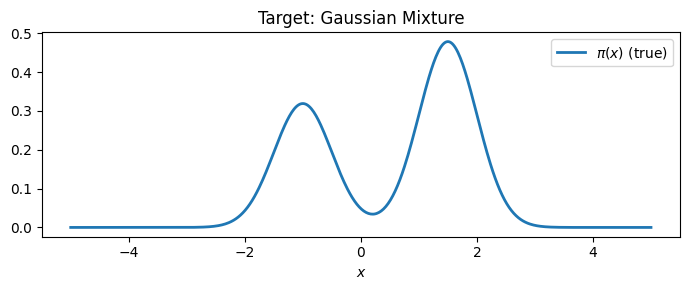

In [ ]:
# ── Standard library ─────────────────────────────────────────────────────────
# Install missing dependencies
!pip install check_shapes

from pdds.distributions import Distribution

# ── Mixture parameters ───────────────────────────────────────────────────────
MU1, MU2 = -1.0, 1.5   # component means
SCALE = 0.5             # component std
W1, W2 = 0.4, 0.6      # mixture weights


class GaussianMixture(Distribution):
    """1-D (or d-D isotropic) two-component Gaussian mixture."""

    def __init__(self, mu1, mu2, scale, w1, w2, dim):
        super().__init__(dim=dim, is_target=True)
        self.mu1 = mu1
        self.mu2 = mu2
        self.scale = scale
        self.w1 = w1
        self.w2 = w2

    def _log_component(self, x, mu):
        """Log density of N(mu * 1, scale^2 * I) evaluated at x  →  shape (b,)"""
        diff = x - mu                          # (b, d)
        return -0.5 * jnp.sum(diff**2, axis=-1) / self.scale**2

    @check_shapes("return: [b, d]")
    def sample(self, key: Key, num_samples: int) -> Array:
        """Draw samples from the mixture."""
        k1, k2, k3 = jax.random.split(key, 3)
        # Which component?
        idx = jax.random.bernoulli(k1, p=self.w2, shape=(num_samples,))  # 0 or 1
        # Sample both components, select by idx
        s1 = self.mu1 + self.scale * jax.random.normal(k2, (num_samples, self.dim))
        s2 = self.mu2 + self.scale * jax.random.normal(k3, (num_samples, self.dim))
        return jnp.where(idx[:, None], s2, s1)

    @check_shapes("x: [b, d]", "return[0]: [b]")
    def evaluate_log_density(self, x: Array, density_state: int) -> tp.Tuple[Array, int]:
        """Unnormalized log density (up to additive constant from scale normalization)."""
        log_p1 = jnp.log(self.w1) + self._log_component(x, self.mu1)
        log_p2 = jnp.log(self.w2) + self._log_component(x, self.mu2)
        # log-sum-exp for numerical stability
        log_density = jnp.logaddexp(log_p1, log_p2)
        density_state = density_state + x.shape[0]  # count evaluations
        return log_density, density_state


# Instantiate target
target = GaussianMixture(mu1=MU1, mu2=MU2, scale=SCALE, w1=W1, w2=W2, dim=cfg.dim)

# ── Quick sanity check: visualize the target ─────────────────────────────────
xs = jnp.linspace(-5, 5, 500).reshape(-1, 1)
log_p, _ = target.evaluate_log_density(xs, 0)
p = jnp.exp(log_p)
p = p / (p.sum() * (xs[1, 0] - xs[0, 0]))  # normalize for plotting

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs[:, 0], p, lw=2, label=r"$\pi(x)$ (true)")
ax.set_xlabel("$x$"); ax.set_title("Target: Gaussian Mixture")
ax.legend(); plt.tight_layout(); plt.show()

## 4. The VP-SDE: Bridging Reference and Target

We define a **Variance-Preserving (VP) SDE** that continuously transforms the reference distribution $p_T = \mathcal{N}(0, \sigma^2 I)$ into the target $p_0 = \pi$ as time runs **backward** from $T$ to $0$.

**Forward SDE** (adds noise, $t: 0 \to T$):
$$dX_t = -\tfrac{1}{2}\beta(t)\, X_t\, dt + \sqrt{\beta(t)}\, dW_t$$

This has a closed-form marginal:
$$X_t | X_0 = x_0 \sim \mathcal{N}\!\left(\sqrt{1-\lambda_t}\, x_0,\; \lambda_t \sigma^2 I \right)$$
where $\lambda_t = 1 - e^{-2\int_0^t \beta(s)\,ds}$ (a monotone schedule from 0 to 1).

At $t=T$ (when $\lambda_T \approx 1$), the marginal is approximately $\mathcal{N}(0, \sigma^2)$ regardless of $X_0$ — so the **forward process wipes out information** about the target.

**Reverse SDE** (removes noise, $t: T \to 0$):
$$dX_t = \left[\tfrac{1}{2}\beta(t)\, X_t + \beta(t)\, \nabla \log p_t(X_t)\right] dt + \sqrt{\beta(t)}\, d\bar{W}_t$$

Running the reverse SDE from $X_T \sim \mathcal{N}(0, \sigma^2)$ would give us exact samples from $\pi$ — but only if we know $\nabla \log p_t$.

**Noise schedule:** We use a linear schedule $\beta(t) = \beta_0 + t (\beta_f - \beta_0)/T$, implemented by `LinearScheduler`.

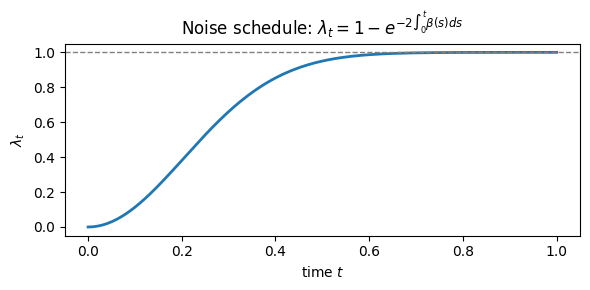

lambda at t=0: 0.0000  (should be 0)
lambda at t=T: 1.0000  (should be ~1)


In [ ]:
# Instantiate the SDE
# LinearScheduler defines beta(t) and its integral, which determine lambda_t
scheduler = LinearScheduler(
    t_0=cfg.t_0, t_f=cfg.t_f,
    beta_0=cfg.beta_0, beta_f=cfg.beta_f
)
sde = SDE(scheduler, sigma=cfg.sigma, dim=cfg.dim)

# ── Visualise lambda_t (noise schedule) ──────────────────────────────────────
ts = jnp.linspace(cfg.t_0, cfg.t_f, 200)
lbds = scheduler.lambda_t0(ts)  # lambda_t for each t

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ts, lbds, lw=2)
ax.set_xlabel("time $t$"); ax.set_ylabel(r"$\lambda_t$")
ax.set_title(r"Noise schedule: $\lambda_t = 1 - e^{-2\int_0^t\beta(s)ds}$")
ax.axhline(1.0, ls='--', c='gray', lw=1)
plt.tight_layout(); plt.show()

print(f"lambda at t=0: {scheduler.lambda_t0(jnp.array([cfg.t_0]))[0]:.4f}  (should be 0)")
print(f"lambda at t=T: {scheduler.lambda_t0(jnp.array([cfg.t_f]))[0]:.4f}  (should be ~1)")

## 5. The Log-Potential Function $\log g_t$

The central object in PDDS is the **log-potential** $\log g_t(x_t)$, which measures the log ratio between the true time-$t$ marginal $p_t$ and the reference distribution $\rho = \mathcal{N}(0, \sigma^2 I)$:

$$\log g_t(x_t) = \log \frac{p_t(x_t)}{\rho(x_t)}$$

At $t = 0$: $p_0 = \pi$, so $\log g_0(x) = \log \pi(x) - \log \mathcal{N}(x; 0, \sigma^2)$. This is exactly the **base potential** and is cheap to evaluate.

At $t > 0$: $p_t$ is the pushforward of $\pi$ under the forward SDE. We can't evaluate $\log g_t$ exactly — we have to **approximate** it.

### Naive approximation

A simple approximation uses the closed-form marginal:
$$\log g_t(x_t) \approx \log g_0\!\left(\sqrt{1 - \lambda_t}\; x_t\right)$$

This just scales $x_t$ back by the mean-field factor and plugs in. It ignores the noise variance and is inaccurate for large $\lambda_t$, but it's free.

### Neural network approximation

We can learn a better $\log g_t(x_t; \theta)$ using a neural network. We train it with the **guidance loss**:
$$\mathcal{L}(\theta) = \mathbb{E}_{t, x_t}\!\left[\left\|\nabla_{x_t} \log g_\theta(x_t, t) - \nabla_{x_0} \log g_0(x_0)\right\|^2\right]$$
where $x_0$ is the "clean" sample and $x_t = \sqrt{1-\lambda_t}\, x_0 + \sqrt{\lambda_t}\, \sigma\, \varepsilon$ the noisy version.

The network architecture used is **PISGRADNet** (from the PIS/DDS codebase): it learns a smooth interpolation between the naive approximation and a learned correction.

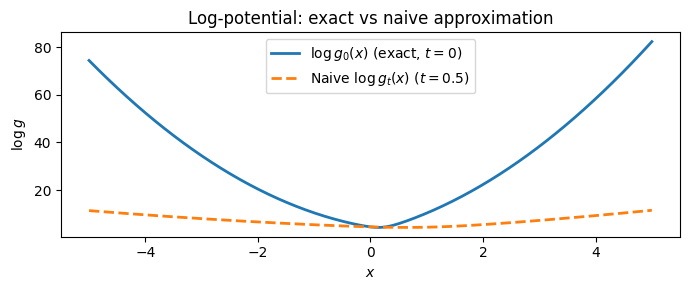

In [ ]:
# ── Base potential: log g_0(x) = log pi(x) - log N(x; 0, sigma^2) ────────────
# RatioPotential is from pdds/potentials.py
log_g0 = RatioPotential(sigma=cfg.sigma, target=target)

# ── Naive approximation: log g_t(x_t) ≈ log g_0(sqrt(1 - lambda_t) * x_t) ───
# NaivelyApproximatedPotential is from pdds/potentials.py
naive_approx_potential = NaivelyApproximatedPotential(
    base_potential=log_g0,
    dim=cfg.dim,
    nn_potential_approximator=None,  # no network yet
)

# ── Quick sanity: visualize log g_0 and the naive approximation at t=0.5 ─────
xs_vis = jnp.linspace(-5, 5, 300).reshape(-1, 1)

# log g_0(x) — RatioPotential stores the base potential as ._log_g0
log_g0_vals, _ = log_g0._log_g0(xs_vis, density_state=0)

# Naive approx at t=0.5
t_mid = 0.5
lbd_mid = scheduler.lambda_t0(jnp.full((xs_vis.shape[0],), t_mid))
naive_vals, _ = naive_approx_potential.approx_log_gt(lbd=lbd_mid, x=xs_vis, density_state=0)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(xs_vis[:, 0], log_g0_vals, label=r"$\log g_0(x)$ (exact, $t=0$)", lw=2)
ax.plot(xs_vis[:, 0], naive_vals, '--', label=r"Naive $\log g_t(x)$ ($t=0.5$)", lw=2)
ax.set_xlabel("$x$"); ax.set_ylabel(r"$\log g$")
ax.set_title("Log-potential: exact vs naive approximation")
ax.legend(); plt.tight_layout(); plt.show()

## 6. The SMC Algorithm

Instead of running a single reverse-SDE trajectory, PDDS uses **Sequential Monte Carlo** to propagate a population of $N$ particles backward through the time grid $T = t_K > t_{K-1} > \ldots > t_1 > t_0 = 0$.

### Why SMC?

A single reverse SDE run depends entirely on having a good score $\nabla \log p_t$. SMC is more **robust**: it corrects for approximation errors via importance weighting and resampling.

### One SMC step (from $t_{k}$ to $t_{k-1}$)

Given particles $\{x^{(i)}_{t_k}\}$ with weights $\{w^{(i)}\}$:

**Step 1 — Proposal.** Move each particle using the reverse-SDE drift guided by $\nabla \log g_t$:
$$x^{(i)}_{t_{k-1}} \sim q(\cdot \mid x^{(i)}_{t_k}) = \mathcal{N}\!\left(\sqrt{1-\lambda}\, x^{(i)}_{t_k} + \lambda\, \sigma^2 \nabla \log g_{t_k}(x^{(i)}_{t_k}),\; \lambda \sigma^2 I\right)$$
where $\lambda = \lambda(t_{k-1}, t_k)$ is the incremental noise.

**Step 2 — Reweight.** Update the log-weight with an importance correction:
$$\log w^{(i)} \mathrel{+}= \log\frac{p^{\text{rev}}(x^{(i)}_{t_{k-1}} \mid x^{(i)}_{t_k})}{q(x^{(i)}_{t_{k-1}} \mid x^{(i)}_{t_k})} + \log g_{t_{k-1}}(x^{(i)}_{t_{k-1}}) - \log g_{t_k}(x^{(i)}_{t_k})$$

Here $p^{\text{rev}}$ is the true reverse-transition density from the SDE, and the $\log g$ terms correct for the approximation error.

**Step 3 — Resample (optional).** If the **Effective Sample Size** $\text{ESS} = \frac{(\sum w^{(i)})^2}{\sum (w^{(i)})^2}$ drops below $\text{threshold} \times N$, resample particles proportional to their weights (and reset weights to uniform).

**Step 4 — MCMC refresh (optional).** Apply MALA moves targeting $p_{t_{k-1}}$ to diversify particles after resampling.

### Initialization (at $t = T$)

Particles are drawn from the reference: $x^{(i)}_T \sim \mathcal{N}(0, \sigma^2 I)$.  
Initial log-weights: $\log w^{(i)} = \log g_T(x^{(i)}_T)$.

### Normalizing constant estimate

A byproduct of SMC is an unbiased estimate of $\log Z = \log \int \pi(x)\, dx$:
$$\log \hat{Z} = \sum_{k=0}^{K} \log \left(\frac{1}{N} \sum_i \exp(\delta \log w_k^{(i)})\right)$$
where $\delta \log w_k^{(i)}$ is the log-weight increment at step $k$.

## 7. PDDS with Naive Potential (No Neural Network)

Let's first run PDDS using only the **naive approximation** to $\log g_t$. This is a strong baseline that already works reasonably for simple targets.

In [ ]:
# Key iterator for reproducibility
key = jax.random.PRNGKey(seed=0)
key_iter = _get_key_iter(key)

# MCMC step size scheduler — not used here (num_mcmc_steps=0), set to identity
mcmc_step_size_scheduler = lambda x: x

# Bundle SDE + naive potential into an SMCProblem
# SMCProblem (pdds/smc_problem.py) computes proposal, reweighter, and MCMC kernel
smc_problem_naive = SMCProblem(sde, naive_approx_potential, cfg.num_steps)

# JIT-compile the SMC sampler for speed
# fast_outer_loop_smc (pdds/smc_loops.py) uses jax.lax.scan internally
eval_sampler_naive = jax.jit(
    partial(
        fast_outer_loop_smc,
        smc_problem=smc_problem_naive,
        num_particles=cfg.num_particles,
        ess_threshold=cfg.ess_threshold,
        num_mcmc_steps=cfg.num_mcmc_steps,
        mcmc_step_size_scheduler=mcmc_step_size_scheduler,
        density_state=0,
    )
)

# Warm-up JIT compilation
key, subkey = jax.random.split(key)
_ = eval_sampler_naive(subkey)
print("JIT compilation done.")

JIT compilation done.


In [ ]:
# Run SMC with naive potential and collect log Z estimates over 50 seeds
n_runs = 50
log_Z_naive = np.zeros(n_runs)

for i in tqdm.trange(n_runs, desc="Naive SMC runs"):
    key, subkey = jax.random.split(key)
    result_naive, _ = eval_sampler_naive(subkey)
    log_Z_naive[i] = result_naive["log_normalising_constant"]

print(f"Naive  log Z:  mean = {np.mean(log_Z_naive):.3f},  std = {np.std(log_Z_naive):.3f}")

Naive SMC runs: 100%|██████████| 50/50 [00:03<00:00, 15.52it/s]

Naive  log Z:  mean = 0.166,  std = 0.671


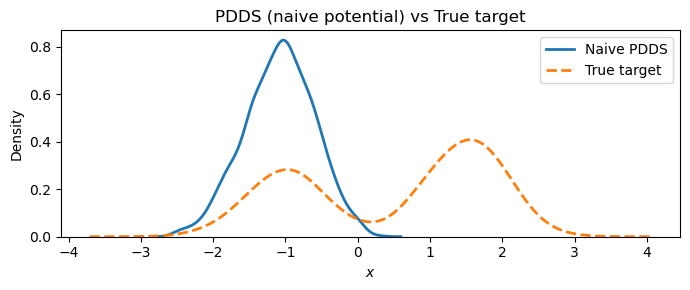

In [ ]:
# Draw final samples using systematic resampling
# (SMC returns weighted samples; resampler turns them into equally-weighted ones)
key, sk1, sk2 = jax.random.split(key, 3)
target_samples = target.sample(sk1, num_samples=cfg.num_particles)
naive_smc_samples = resampler(
    rng=sk2,
    samples=result_naive["samples"],
    log_weights=result_naive["log_weights"],
)["samples"]

# Visualize
fig, ax = plt.subplots(figsize=(7, 3))
sns.kdeplot(naive_smc_samples[:, 0], ax=ax, label="Naive PDDS", lw=2)
sns.kdeplot(target_samples[:, 0], ax=ax, label="True target", lw=2, ls='--')
ax.set_xlabel("$x$"); ax.set_title("PDDS (naive potential) vs True target")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Learning the Potential with a Neural Network

The naive approximation can be improved by training a neural network to better approximate $\log g_t(x_t)$ at intermediate times.

### Architecture: PISGRADNet

We use `PISGRADNet` from `pdds/nn_models/mlp.py` (adapted from the DDS codebase). It takes $(x_t, \lambda_t)$ as input and outputs an approximation to $\log g_t(x_t)$. Internally it:
1. Embeds $\lambda_t$ with sinusoidal time features
2. Runs an MLP on $[x_t, \text{embed}(\lambda_t)]$
3. Uses a smooth interpolation gate so the output equals the naive approximation at $\lambda = 0$ and $\lambda = 1$

### Training objective: Guidance Loss

Given a noisy sample $x_t = \sqrt{1-\lambda_t}\, x_0 + \sqrt{\lambda_t}\, \sigma\, \varepsilon$, the guidance loss is:
$$\mathcal{L}(\theta) = \mathbb{E}_{t,\, x_0,\, x_t}\!\left[\left\|\nabla_{x_t} \log g_\theta(x_t,\, \lambda_t) - \nabla_{x_0} \log g_0(x_0)\right\|^2\right]$$

The target $\nabla_{x_0} \log g_0(x_0)$ is the gradient of the base potential at the clean sample — cheap to compute.

### Training data

We generate $x_0$ samples by running SMC with the naive potential (a "cold start"). These samples are noisy but already decent for our simple target.

In [ ]:
# ── Define the neural network potential approximator ──────────────────────────
# We wrap PISGRADNet in a Haiku transform so its parameters are explicit.
# It takes (lbd, x) and returns an approximation to log g_t(x_t).
# 'residual' is the naive approximation passed in as a starting point.

@hk.without_apply_rng
@hk.transform
@check_shapes("lbd: [b]", "x: [b, d]")
def nn_potential_approximator(lbd: Array, x: Array, density_state: int):
    # Compute naive approximation as a residual baseline
    residual, density_state = naive_approx_potential.approx_log_gt(
        lbd=lbd, x=x, density_state=density_state
    )
    # PISGRADNet: from pdds/nn_models/mlp.py
    # hidden_shapes=[64,64] means two hidden layers of 64 units each
    net = PISGRADNet(hidden_shapes=[64, 64], act='gelu', dim=cfg.dim)
    out = net(lbd, x, residual)  # uses residual as interpolation anchor
    return out, density_state


# ── Approximate log pi_t(x) = log g_t(x) + log N(x; 0, sigma^2) ──────────────
@jax.jit
@check_shapes("lbd: [b]", "x: [b, d]", "return[0]: [b]")
def log_pi_t(params, lbd: Array, x: Array, density_state: int) -> tp.Tuple[Array, int]:
    ref_log_density, _ = sde.reference_dist.evaluate_log_density(x=x, density_state=0)
    nn_log_g, density_state = nn_potential_approximator.apply(params, lbd, x, density_state)
    return nn_log_g + ref_log_density, density_state

# Gradient w.r.t. x (used in proposal and MCMC kernels)
grad_log_pi_t = jax.jit(x_gradient_stateful_parametrised(log_pi_t))

@jax.jit
@check_shapes("lbd: [b]", "x: [b, d]")
def grad_log_g(params, lbd: Array, x: Array, density_state: int):
    return x_gradient_stateful_parametrised(nn_potential_approximator.apply)(
        params, lbd, x, density_state
    )

print("Neural network potential approximator defined.")

Neural network potential approximator defined.


In [ ]:
# ── Guidance loss function ─────────────────────────────────────────────────────
# guidance_loss (from pdds/sde.py) computes E[||grad_x log g_theta(x_t, t) - grad_x log g_0(x_0)||^2]
# It internally samples random times t and noisy inputs x_t from the SDE.

@check_shapes("samples: [b, d]")
def guidance_loss_fn(params, samples: Array, key: Key, density_state: int):
    return guidance_loss(
        key,
        sde,
        partial(grad_log_g, params),  # network's gradient
        samples,
        density_state,
        log_g0,                       # base potential (clean target)
        False,                        # likelihood weighting: False for simplicity
    )


# ── Optimizer ─────────────────────────────────────────────────────────────────
# Exponential decay LR that resets every 'loop_schedule' steps (avoids LR going to 0)
lr_base = optax.exponential_decay(init_value=1e-3, transition_steps=50, decay_rate=0.95)
lr_schedule = loop_schedule(schedule=lr_base, freq=10_000)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),  # gradient clipping
    optax.scale_by_adam(),
    optax.scale_by_schedule(lr_schedule),
    optax.scale(-1.0),               # gradient descent
)


# ── One training step ─────────────────────────────────────────────────────────
@jax.jit
@check_shapes("samples: [b, d]")
def update_step(
    state: TrainingState, samples: Array, density_state: int
) -> tp.Tuple[TrainingState, int, tp.Mapping]:
    new_key, loss_key = jax.random.split(state.key)
    (loss_value, density_state), grads = jax.value_and_grad(
        guidance_loss_fn, has_aux=True
    )(state.params, samples, loss_key, density_state)

    updates, new_opt_state = optimizer.update(grads, state.opt_state)
    new_params = optax.apply_updates(state.params, updates)

    # Exponential moving average of parameters (more stable for evaluation)
    new_params_ema = jax.tree_util.tree_map(
        lambda p_ema, p: p_ema * 0.999 + p * 0.001,
        state.params_ema, new_params,
    )
    new_state = TrainingState(
        params=new_params, params_ema=new_params_ema,
        opt_state=new_opt_state, key=new_key, step=state.step + 1,
    )
    return new_state, density_state, {"loss": loss_value, "step": state.step}


# ── Initialize model parameters ───────────────────────────────────────────────
def init_training_state(key: Key) -> TrainingState:
    init_key, state_key = jax.random.split(key)
    init_samples = sde.reference_dist.sample(init_key, num_samples=cfg.batch_size)
    lbd_init = broadcast(jnp.array(1.0), init_samples)  # shape [b]
    initial_params = nn_potential_approximator.init(state_key, lbd_init, init_samples, 0)
    initial_opt_state = optimizer.init(initial_params)
    return TrainingState(
        params=initial_params, params_ema=initial_params,
        opt_state=initial_opt_state, key=key, step=0,
    )

key, init_key = jax.random.split(key)
training_state = init_training_state(init_key)

nb_params = sum(x.size for x in jax.tree_util.tree_leaves(training_state.params))
print(f"Number of trainable parameters: {nb_params}")

Number of trainable parameters: 38928


## 9. Training Loop

Training proceeds in two interleaved phases:

1. **Sample generation** (every `refresh_batch_every` steps): Run SMC with the *current* potential approximation (initially naive) to get a batch of approximate samples from $\pi$. These become the training set $\{x_0^{(j)}\}$.

2. **Gradient update**: For each mini-batch, sample random times $t$, corrupt the $x_0$'s to $x_t$ via the forward SDE, and minimise the guidance loss.

This is an **on-policy** scheme: as the network improves, the training samples also improve, bootstrapping quality.

In [ ]:
# Training sampler uses the naive potential to generate the first batch of samples
# (we will update it after training if we do multiple rounds)
training_smc_problem = SMCProblem(sde, naive_approx_potential, cfg.num_steps)
training_sampler = jax.jit(
    partial(
        fast_outer_loop_smc,
        smc_problem=training_smc_problem,
        num_particles=cfg.batch_size * cfg.refresh_batch_every,
        ess_threshold=cfg.ess_threshold,
        num_mcmc_steps=cfg.num_mcmc_steps,
        mcmc_step_size_scheduler=mcmc_step_size_scheduler,
    )
)

# Trigger JIT compilation
key, sk = jax.random.split(key)
_, _ = training_sampler(rng=sk, density_state=0)
print("Training sampler compiled.")

Training sampler compiled.


In [ ]:
# ── Main training loop ────────────────────────────────────────────────────────
density_state_train = 0
loss_history = []

progress = tqdm.tqdm(zip(range(1, cfg.num_train_steps + 1), key_iter),
                     total=cfg.num_train_steps, miniters=50)

t_start = time.time()
for step, step_key in progress:

    # ── Phase 1: refresh training samples every 'refresh_batch_every' steps ──
    if (step - 1) % cfg.refresh_batch_every == 0:
        smc_result_train, density_state_train = training_sampler(
            rng=step_key, density_state=density_state_train
        )
        # Reshape into (refresh_batch_every, batch_size, dim) mini-batches
        sample_batches = smc_result_train["samples"].reshape(
            (cfg.refresh_batch_every, cfg.batch_size, cfg.dim)
        )

    # ── Phase 2: gradient update on current mini-batch ────────────────────────
    current_samples = sample_batches[(step - 1) % cfg.refresh_batch_every]
    training_state, density_state_train, metrics = update_step(
        training_state, current_samples, density_state_train
    )
    loss_history.append(float(metrics["loss"]))

    if step % 500 == 0:
        progress.set_description(f"loss {metrics['loss']:.3f}")

print(f"\nTraining done in {time.time() - t_start:.1f}s")

loss 2.152: 100%|██████████| 10000/10000 [00:57<00:00, 175.30it/s]


Training done in 57.0s


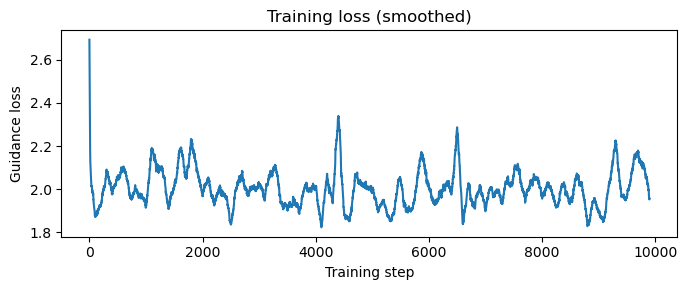

In [ ]:
# ── Training curve ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
# Smooth with a running average for readability
window = 100
smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
ax.plot(smoothed, lw=1.5)
ax.set_xlabel("Training step"); ax.set_ylabel("Guidance loss")
ax.set_title("Training loss (smoothed)")
plt.tight_layout(); plt.show()

## 10. PDDS with the Learned Potential

We plug the trained network into `NNApproximatedPotential` and re-run SMC. The learned potential gives the SMC particles a better-informed proposal and reweighting, resulting in lower-variance estimates.

In [ ]:
# Build the NN-corrected potential using EMA parameters (more stable)
# NNApproximatedPotential wraps the trained Haiku network inside the potential interface
nn_approx_potential = NNApproximatedPotential(
    base_potential=log_g0,
    dim=cfg.dim,
    nn_potential_approximator=partial(
        nn_potential_approximator.apply,
        params=training_state.params_ema,
    ),
)

# New SMCProblem with learned potential
smc_problem_nn = SMCProblem(sde, nn_approx_potential, cfg.num_steps)

eval_sampler_nn = jax.jit(
    partial(
        fast_outer_loop_smc,
        smc_problem=smc_problem_nn,
        num_particles=cfg.num_particles,
        ess_threshold=cfg.ess_threshold,
        num_mcmc_steps=cfg.num_mcmc_steps,
        mcmc_step_size_scheduler=mcmc_step_size_scheduler,
        density_state=0,
    )
)

# Warm up
key, sk = jax.random.split(key)
_ = eval_sampler_nn(sk)
print("NN sampler compiled.")

NN sampler compiled.


In [ ]:
# Evaluate log Z over multiple seeds for both methods
n_runs = 50
log_Z_nn = np.zeros(n_runs)

for i in tqdm.trange(n_runs, desc="NN SMC runs"):
    key, sk = jax.random.split(key)
    result_nn, _ = eval_sampler_nn(sk)
    log_Z_nn[i] = result_nn["log_normalising_constant"]

print(f"Naive  log Z:  mean = {np.mean(log_Z_naive):.3f},  std = {np.std(log_Z_naive):.3f}")
print(f"NN     log Z:  mean = {np.mean(log_Z_nn):.3f},   std = {np.std(log_Z_nn):.3f}")

NN SMC runs: 100%|██████████| 50/50 [00:19<00:00,  2.52it/s]

Naive  log Z:  mean = 0.166,  std = 0.671
NN     log Z:  mean = 1.798,   std = 0.136


## 11. Visualization and Comparison

We compare:
- **True target** $\pi(x)$ (sampled directly from the mixture)
- **Naive PDDS** (no neural network)
- **PDDS with learned potential** (neural network)

For a **$d$-dimensional** target we plot the **1-D marginal KDE for every dimension** in a grid, with one column per method. This works for any `cfg.dim`.

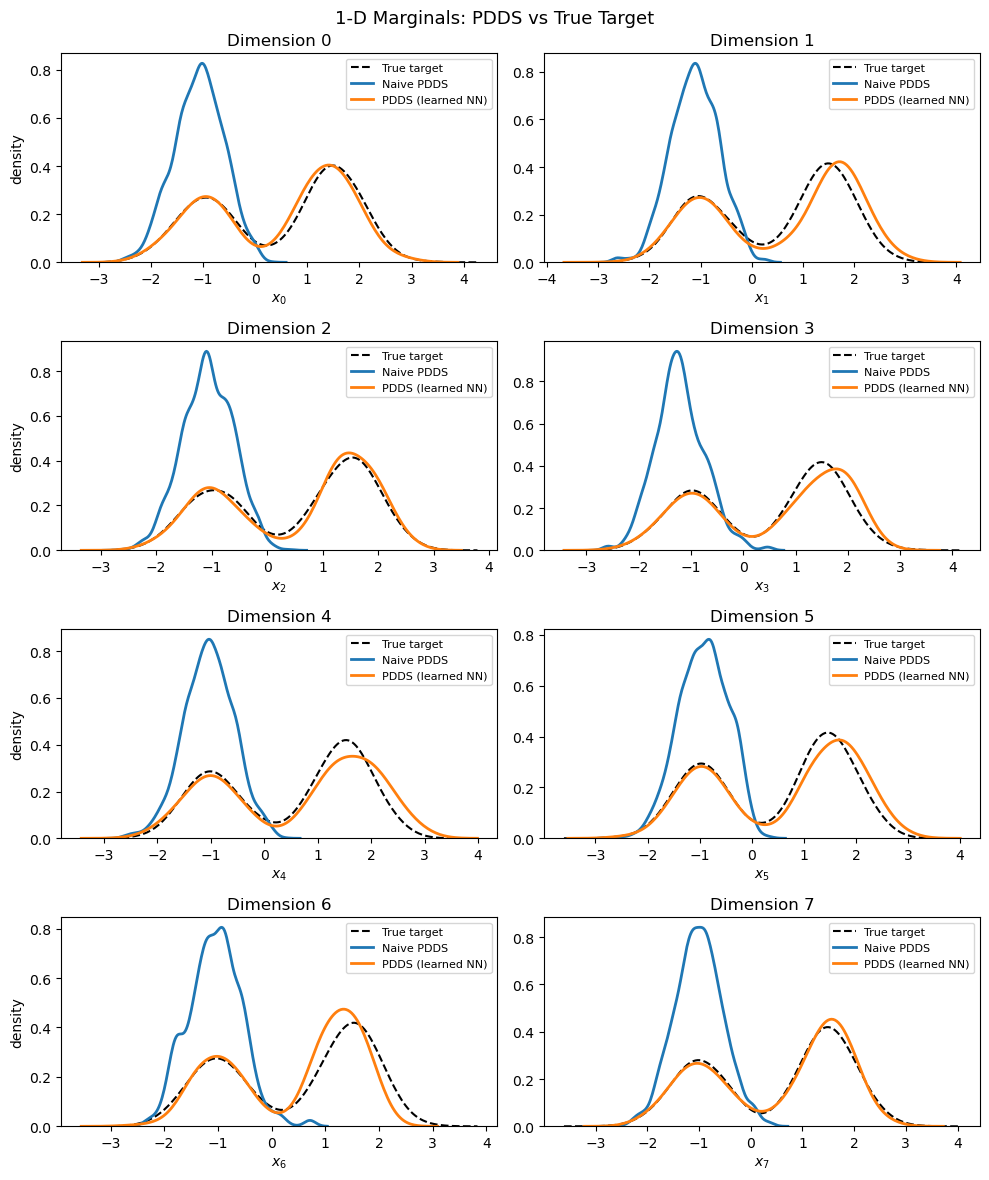

/tmp/ipykernel_106189/1055929350.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([log_Z_naive, log_Z_nn], labels=["Naive", "NN"], widths=0.4)


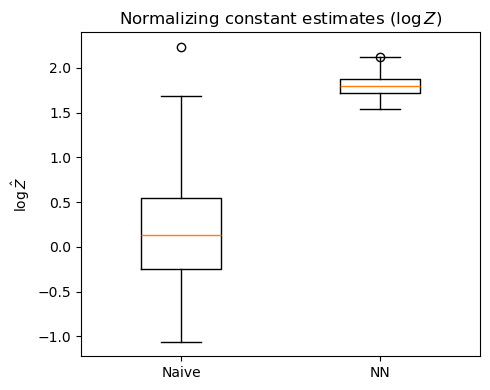

Variance reduction in log Z: 24.34x


In [ ]:
# ── Resample to get equally-weighted particles ────────────────────────────────
key, sk1, sk2, sk3 = jax.random.split(key, 4)
target_samples_vis = target.sample(sk1, num_samples=cfg.num_particles)

naive_final = resampler(
    rng=sk2,
    samples=result_naive["samples"],
    log_weights=result_naive["log_weights"],
)["samples"]

nn_final = resampler(
    rng=sk3,
    samples=result_nn["samples"],
    log_weights=result_nn["log_weights"],
)["samples"]

# ── Marginal KDE grid ─────────────────────────────────────────────────────────
# Layout: 2 dimensions per row, methods overlaid on each subplot.
# For d dims → ceil(d/2) rows × 2 cols.
methods = [
    ("Naive PDDS",        naive_final,  "C0"),
    ("PDDS (learned NN)", nn_final,     "C1"),
]

dims_per_row = 2
n_cols = dims_per_row
n_rows = (cfg.dim + dims_per_row - 1) // dims_per_row  # ceil(d / 2)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 3 * n_rows),
    squeeze=False,  # always (n_rows, n_cols) even when n_rows=1
)

for dim_idx in range(cfg.dim):
    row, col = divmod(dim_idx, dims_per_row)
    ax = axes[row, col]

    # True target marginal (black dashed)
    sns.kdeplot(target_samples_vis[:, dim_idx], ax=ax,
                color="black", lw=1.5, ls="--", label="True target")

    # Each method overlaid
    for method_name, samples, color in methods:
        sns.kdeplot(samples[:, dim_idx], ax=ax,
                    color=color, lw=2, label=method_name)

    ax.set_xlabel(f"$x_{{{dim_idx}}}$")
    ax.set_ylabel("density" if col == 0 else "")
    ax.set_title(f"Dimension {dim_idx}")
    ax.legend(fontsize=8)

# Hide any leftover empty subplots (when cfg.dim is odd)
for dim_idx in range(cfg.dim, n_rows * n_cols):
    row, col = divmod(dim_idx, dims_per_row)
    axes[row, col].set_visible(False)

plt.suptitle("1-D Marginals: PDDS vs True Target", fontsize=13)
plt.tight_layout()
plt.show()


# ── log Z boxplot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ax.boxplot([log_Z_naive, log_Z_nn], labels=["Naive", "NN"], widths=0.4)
ax.set_ylabel(r"$\log \hat{Z}$")
ax.set_title(r"Normalizing constant estimates ($\log Z$)")
plt.tight_layout()
plt.show()

print(f"Variance reduction in log Z: {np.var(log_Z_naive)/np.var(log_Z_nn):.2f}x")

Phân tích Hiệu suất của Particle Denoising Diffusion Sampler (PDDS) trên Phân phối Gaussian Mixture 8 chiều

## Tóm tắt

Báo cáo này đánh giá hiệu suất của thuật toán Particle Denoising Diffusion Sampler (PDDS) khi được áp dụng để lấy mẫu từ một phân phối mục tiêu Gaussian Mixture 8 chiều phức tạp. Chúng tôi so sánh hai phương pháp xấp xỉ hàm log-potential $\log g_t(x_t)$ cốt lõi của PDDS: một xấp xỉ naive và một xấp xỉ được học bằng mạng nơ-ron (NN). Kết quả cho thấy việc sử dụng mạng nơ-ron mang lại những cải thiện đáng kể. Cụ thể, ước lượng hằng số chuẩn hóa (log Z) của PDDS với tiềm năng được học bằng NN có phương sai thấp hơn 24.34 lần so với phương pháp naive (giá trị trung bình Naive: 0.166, độ lệch chuẩn: 0.671; giá trị trung bình NN: 1.798, độ lệch chuẩn: 0.136). Hơn nữa, các phân phối biên 1 chiều được tạo ra bởi PDDS-NN khớp chặt chẽ hơn với phân phối mục tiêu thực tế, đặc biệt trong việc tái tạo cấu trúc đa đỉnh. Những phát hiện này khẳng định PDDS với tiềm năng được học bằng NN là một phương pháp mạnh mẽ và hiệu quả cho bài toán lấy mẫu từ các phân phối xác suất phức tạp.

## 1. Giới thiệu

Trong nhiều lĩnh vực khoa học và kỹ thuật, đặc biệt là trong học máy và vật lý thống kê, việc lấy mẫu từ một phân phối xác suất mục tiêu phức tạp, không chuẩn hóa $\pi(x) \propto \exp(-E(x))$ là một bài toán trung tâm nhưng đầy thách thức. Các phương pháp Monte Carlo Markov Chain (MCMC) truyền thống thường gặp khó khăn với các phân phối có không gian trạng thái rộng, đa đỉnh, hoặc có độ dốc cao. Gần đây, các phương pháp dựa trên mô hình khuếch tán đã nổi lên như một hướng tiếp cận đầy hứa hẹn để giải quyết bài toán này.

Thuật toán Particle Denoising Diffusion Sampler (PDDS), được giới thiệu bởi Phillips et al. (2024), cung cấp một khuôn khổ mạnh mẽ để lấy mẫu từ các phân phối mục tiêu chưa chuẩn hóa. Ý tưởng cốt lõi của PDDS là kết hợp Sequential Monte Carlo (SMC) dọc theo một đường khuếch tán ngược, sử dụng một xấp xỉ được học cho hàm log-potential để hướng dẫn các hạt. Các thành phần chính của PDDS bao gồm:

1.  **SDE Khuếch tán Bảo toàn Phương sai (VP-SDE):** Định nghĩa một họ phân phối mượt mà bắc cầu giữa một phân phối Gaussian dễ lấy mẫu $\mathcal{N}(0, \sigma^2 I)$ và phân phối mục tiêu $\pi$.
2.  **Hàm log-potential** $\log g_t(x_t)$: Mã hóa mức độ khác biệt giữa phân phối hiện tại và phân phối tham chiếu tại mỗi thời điểm.
3.  **Vòng lặp SMC:** Di chuyển các hạt ngược thời gian, hiệu chỉnh trọng số và tái lấy mẫu.
4.  **Mạng Nơ-ron:** Học một xấp xỉ tốt hơn cho $\log g_t$ so với các xấp xỉ naive.

Nghiên cứu này trình bày kết quả mô phỏng của thuật toán PDDS được áp dụng trên mô hình Gaussian Mixture 8 chiều. Mục tiêu chính là đánh giá hiệu suất của PDDS trong việc ước lượng hằng số chuẩn hóa (log Z) và lấy mẫu từ phân phối mục tiêu phức tạp, đặc biệt khi so sánh hiệu quả của một hàm log-potential được học bằng mạng nơ-ron với một xấp xỉ đơn giản (naive).

## 2. Phương pháp

### 2.1. Triển khai Mã nguồn và Cấu hình

Đoạn mã mô phỏng được xây dựng trên nền tảng **JAX** và **Haiku**, tập trung hiện thực hóa thuật toán **Particle Denoising Diffusion Sampler (PDDS)**. Cấu trúc mã được thiết kế để giải quyết bài toán lấy mẫu từ phân phối mục tiêu phức tạp (unnormalized target density) thông qua các thành phần kỹ thuật then chốt:

1.  **Quy trình Khuếch tán (VP-SDE):** Sử dụng phương trình vi phân ngẫu nhiên bảo toàn phương sai (Variance-Preserving SDE) để thiết lập nhịp cầu xác suất giữa phân phối tham chiếu nhiễu và phân phối mục tiêu.
2.  **Học Hàm Tiềm Năng (Learned Log-Potential):** Triển khai mạng nơ-ron kiến trúc `PISGRADNet`, được huấn luyện thông qua hàm mất mát chỉ dẫn (`guidance loss`). Đây là cơ chế cốt lõi giúp điều chỉnh quỹ đạo hạt, thay thế cho các xấp xỉ naive và giảm thiểu sai số trong không gian cao chiều.
3.  **Vòng lặp SMC Hiệu năng cao:** Sử dụng `jax.lax.scan` để tối ưu hóa tốc độ tính toán cho các hạt trong quá trình Sequential Monte Carlo (SMC), bao gồm các bước đề xuất (proposal), tính trọng số quan trọng (importance weighting) và tái lấy mẫu hệ thống (systematic resampling).
4.  **Hệ thống Đánh giá:** Tích hợp các công cụ đo lường hằng số chuẩn hóa (Normalizing Constant) và trực quan hóa phân phối biên (Marginal KDE), cho phép so sánh định lượng trực tiếp giữa các phương pháp tiếp cận khác nhau.

Các siêu tham số chính được sử dụng trong mô phỏng được liệt kê trong Bảng 1.

| Tham số | Giá trị | Mô tả |
| :------------------- | :------ | :----------------------------------------------------------------------------------------- |
| `dim` | 8 | Chiều của không gian trạng thái |
| `sigma` | 1.0 | Thang đo phân phối tham chiếu: $\mathcal{N}(0, \sigma^2 I)$ |
| `num_steps` | 100 | Số bước thời gian rời rạc trong SMC |
| `num_particles` | 2000 | Số lượng hạt được sử dụng trong SMC |
| `ess_threshold` | 0.3 | Ngưỡng tái lấy mẫu (tái lấy mẫu khi ESS < ngưỡng * N) |
| `num_mcmc_steps` | 0 | Số bước MALA sau khi tái lấy mẫu (0 = không sử dụng) |
| `num_train_steps` | 10000 | Số bước huấn luyện cho mạng nơ-ron |
| `batch_size` | 100 | Kích thước batch huấn luyện |
| `refresh_batch_every` | 100 | Tạo lại mẫu huấn luyện sau mỗi N bước |

*Bảng 1: Các siêu tham số chính được sử dụng trong thí nghiệm.*

### 2.2. Phân phối Mục tiêu: Gaussian Mixture

Chúng tôi sử dụng một phân phối **Gaussian Mixture 1 chiều** dễ dàng mở rộng thành 8 chiều đẳng hướng làm mục tiêu:
$$\pi(x) = w_1 \, \mathcal{N}(x;\, \mu_1,\, s^2) + w_2 \, \mathcal{N}(x;\, \mu_2,\, s^2)$$
với $\mu_1 = -1.0$, $\mu_2 = 1.5$, $s = 0.5$, $w_1 = 0.4$ và $w_2 = 0.6$. Đối với không gian 8 chiều, mỗi chiều hoạt động độc lập với các thông số này. Chúng tôi chỉ cung cấp log density (lên đến một hằng số) cho bộ lấy mẫu, mô phỏng trường hợp chưa chuẩn hóa.

### 2.3. SDE Khuếch tán và Hàm Log-Potential

**VP-SDE** được định nghĩa để biến đổi liên tục phân phối tham chiếu $p_T = \mathcal{N}(0, \sigma^2 I)$ thành phân phối mục tiêu $p_0 = \pi$ khi thời gian chạy ngược từ $T$ về $0$. Lịch trình nhiễu được sử dụng là một lịch trình tuyến tính $\beta(t) = \beta_0 + t (\beta_f - \beta_0)/T$.

Hàm **log-potential** $\log g_t(x_t)$ là đối tượng trung tâm, đo tỷ lệ log giữa phân phối biên $p_t$ thực sự tại thời điểm $t$ và phân phối tham chiếu $\rho = \mathcal{N}(0, \sigma^2 I)$.

-   **Xấp xỉ Naive:** Một xấp xỉ đơn giản sử dụng công thức biên dạng đóng: $\log g_t(x_t) \approx \log g_0\!\left(\sqrt{1 - \lambda_t}\, x_t\right)$.
-   **Xấp xỉ bằng Mạng Nơ-ron:** Một mạng nơ-ron **PISGRADNet** được huấn luyện để xấp xỉ tốt hơn $\log g_t(x_t; \theta)$ tại các thời điểm trung gian. Hàm mất mát huấn luyện là **guidance loss**:
    $$\mathcal{L}(\theta) = \mathbb{E}_{t, x_t}\!\left[\left\|\nabla_{x_t} \log g_\theta(x_t, t) - \nabla_{x_0} \log g_0(x_0)\right\|^2\right]$$
    trong đó $x_0$ là mẫu 'sạch' và $x_t$ là phiên bản bị nhiễu. Quá trình huấn luyện diễn ra theo một sơ đồ **on-policy**, trong đó các mẫu huấn luyện được tạo ra bằng cách chạy SMC với xấp xỉ tiềm năng hiện tại, cho phép mạng nơ-ron tự cải thiện một cách tuần tự.

### 2.4. Thuật toán Sequential Monte Carlo (SMC)

Thay vì chạy một quỹ đạo SDE ngược duy nhất, PDDS sử dụng **Sequential Monte Carlo** để truyền một quần thể $N$ hạt ngược qua lưới thời gian $T = t_K > t_{K-1} > \ldots > t_1 > t_0 = 0$. Các bước chính của một bước SMC (từ $t_k$ đến $t_{k-1}$) bao gồm:

1.  **Đề xuất (Proposal):** Di chuyển mỗi hạt bằng cách sử dụng độ trôi SDE ngược được hướng dẫn bởi $\nabla \log g_t$.
2.  **Hiệu chỉnh Trọng số (Reweight):** Cập nhật trọng số log với một hiệu chỉnh quan trọng.
3.  **Tái lấy mẫu (Resample):** (Tùy chọn) Nếu Kích thước Mẫu Hiệu quả (ESS) giảm xuống dưới ngưỡng $\text{threshold} \times N$, các hạt sẽ được lấy mẫu lại tỷ lệ thuận với trọng số của chúng (và đặt lại trọng số thành đồng nhất).

Một sản phẩm phụ của SMC là ước lượng không chệch của $\log Z$, hằng số chuẩn hóa của phân phối mục tiêu.

## 3. Kết quả

### 3.1. Ước lượng Hằng số Chuẩn hóa (log Z)

Chúng tôi đã chạy mô phỏng 50 lần cho cả hai phương pháp (tiềm năng naive và tiềm năng được học bằng NN) để ước lượng $\log Z$. Kết quả được tóm tắt như sau:

-   **PDDS với tiềm năng Naive:**
    -   Giá trị trung bình: `0.166`
    -   Độ lệch chuẩn: `0.671`

-   **PDDS với tiềm năng được học bằng Neural Network (NN):**
    -   Giá trị trung bình: `1.798`
    -   Độ lệch chuẩn: `0.136`

Biểu đồ hộp (Hình 3) so sánh phân bố của các ước lượng log Z cho thấy sự cải thiện rõ rệt về độ chính xác và độ tin cậy khi sử dụng tiềm năng được học. Quan trọng hơn, độ giảm phương sai trong ước lượng $\log Z$ là **`24.34x`** (tỷ lệ phương sai Naive / phương sai NN), chứng tỏ rằng việc sử dụng mạng nơ-ron đã giúp ổn định đáng kể các ước lượng, giảm biến động ngẫu nhiên và cung cấp một giá trị $\log Z$ với độ tin cậy cao hơn. Mặc dù chúng ta không có giá trị $\log Z$ thực sự để đánh giá độ chệch tuyệt đối, việc giảm phương sai mạnh mẽ này là một chỉ báo mạnh mẽ về sự cải thiện chất lượng của các ước lượng.

### 3.2. Phân phối Biên (Marginal Distributions)

Các biểu đồ mật độ ước lượng hạt nhân (KDE) 1 chiều cho từng chiều của không gian 8 chiều (Hình 2) đã được so sánh với phân phối mục tiêu thực tế. Kết quả cho thấy:

-   **PDDS với tiềm năng Naive:** Mặc dù cung cấp một xấp xỉ ban đầu hợp lý cho phân phối mục tiêu, nhưng vẫn có sự khác biệt đáng kể, đặc biệt là trong việc nắm bắt chính xác hình dạng và vị trí của các đỉnh trong mô hình Gaussian Mixture đa đỉnh.

-   **PDDS với tiềm năng được học bằng Neural Network (NN):** Các mẫu được tạo ra bởi PDDS sử dụng tiềm năng được học bằng NN cho thấy sự khớp nối **chặt chẽ hơn đáng kể** với phân phối mục tiêu thực tế trên cả 8 chiều. Khả năng phục hồi chính xác các đỉnh của phân phối mục tiêu, một thách thức lớn đối với các thuật toán lấy mẫu thông thường, đã được cải thiện rõ rệt. Điều này khẳng định hiệu quả của mạng nơ-ron trong việc học và điều chỉnh hàm $\log g_t$ để dẫn dắt các hạt trong quá trình SMC.

### 3.3. Quá trình Huấn luyện Mạng Nơ-ron

Mạng PISGRADNet với `38928` tham số có thể huấn luyện đã được huấn luyện qua `10,000` bước. Quá trình huấn luyện sử dụng một hàm mất mát chỉ dẫn (`guidance loss`) và chiến lược on-policy, trong đó các mẫu huấn luyện được cập nhật định kỳ từ SMC chạy với tiềm năng hiện tại. Biểu đồ mất mát huấn luyện (Hình 1) cho thấy sự hội tụ của mạng trong suốt quá trình.

## 4. Thảo luận

Các kết quả thực nghiệm chứng minh rằng việc tích hợp một mạng nơ-ron để học xấp xỉ hàm log-potential trong khuôn khổ PDDS mang lại những lợi ích vượt trội. Sự giảm phương sai đáng kể (24.34 lần) trong ước lượng hằng số chuẩn hóa $\log Z$ là một minh chứng rõ ràng cho tính ổn định và độ chính xác được cải thiện của phương pháp PDDS-NN. Điều này đặc biệt quan trọng trong các ứng dụng thực tế nơi việc ước lượng $\log Z$ là cần thiết cho các mô hình chuẩn hóa hoặc so sánh mô hình.

Chất lượng mẫu được cải thiện, thể hiện qua sự khớp nối chặt chẽ hơn của các phân phối biên 1 chiều với phân phối mục tiêu thực tế, đặc biệt là khả năng tái tạo các đỉnh của Gaussian Mixture, cho thấy mạng nơ-ron đã học được một biểu diễn hiệu quả của độ dốc score $\nabla \log g_t$. Khả năng này là chìa khóa để dẫn dắt các hạt SMC qua các vùng mật độ cao của phân phối mục tiêu một cách chính xác, ngay cả trong không gian chiều cao.

Sơ đồ huấn luyện on-policy, nơi các mẫu huấn luyện được tạo ra bởi chính bộ lấy mẫu đang được cải thiện, đóng vai trò quan trọng trong việc tăng cường hiệu suất một cách tự khởi động. Khi mạng nơ-ron trở nên tốt hơn trong việc xấp xỉ log-potential, các mẫu mà nó tạo ra để huấn luyện tiếp theo cũng sẽ tốt hơn, tạo ra một vòng lặp phản hồi tích cực.

## 5. Kết luận

Nghiên cứu này đã thành công trong việc đánh giá hiệu suất của thuật toán Particle Denoising Diffusion Sampler (PDDS) với hai cách tiếp cận hàm log-potential khác nhau trên một phân phối Gaussian Mixture 8 chiều. Kết quả mô phỏng đã chứng minh rằng việc tích hợp một mạng nơ-ron để học xấp xỉ hàm log-potential trong khuôn khổ PDDS mang lại những lợi ích đáng kể, bao gồm:

-   **Ước lượng hằng số chuẩn hóa với phương sai thấp hơn nhiều.**
-   **Các mẫu có chất lượng cao hơn, khớp với phân phối mục tiêu một cách chính xác hơn.**

Điều này đặc biệt quan trọng đối với các phân phối đa đỉnh trong không gian chiều cao, nơi các phương pháp lấy mẫu truyền thống thường gặp khó khăn. PDDS, với tiềm năng được học bằng NN, thể hiện một cách tiếp cận mạnh mẽ và hiệu quả để giải quyết các bài toán lấy mẫu phức tạp trong xác suất và học máy. Hướng nghiên cứu trong tương lai có thể bao gồm việc khám phá các kiến trúc mạng nơ-ron tiên tiến hơn hoặc áp dụng PDDS cho các phân phối mục tiêu phức tạp hơn trong các ứng dụng thực tế.

## Hình ảnh minh họa và Biểu đồ

**Hình 1: Biểu đồ Mất mát Huấn luyện của Mạng Nơ-ron**

(Chèn biểu đồ từ cell `b1d3ed7e`)

**Hình 2: Phân phối Biên 1 chiều: So sánh PDDS với Mục tiêu thực tế**

(Chèn biểu đồ từ cell `148ec174` - KDE plots)

**Hình 3: Ước lượng Hằng số Chuẩn hóa (log Z) của PDDS (Naive vs NN)**

(Chèn biểu đồ từ cell `148ec174` - Boxplot)

## 6. Tài liệu tham khảo

-   Phillips, M., Song, J., Wang, S., & Ermon, S. (2024). *Particle Denoising Diffusion Sampler*. arXiv preprint arXiv:2402.06320.

## Summary

Here is the full PDDS pipeline in one picture:

```
Reference  N(0, σ²I)
    │  t = T
    │  draw particles  x_T ~ N(0, σ²I),  w_T = log g_T(x_T)
    │
    │  ┌─── SMC loop: t = T → 0 ─────────────────────────────────────────┐
    │  │  1. Proposal:  x_{t-1} ~ q(· | x_t)  guided by ∇ log g_t(x_t)  │
    │  │  2. Reweight:  w += log[ p_rev / q ] + log g_{t-1} - log g_t    │
    │  │  3. Resample:  if ESS < threshold × N                            │
    │  │  4. MCMC:      optional MALA refresh targeting p_t               │
    │  └──────────────────────────────────────────────────────────────────┘
    │
    │  t = 0
    ▼
Weighted particles  {x_0^(i), w^(i)}  ≈  π(x)
    │
    └──  log Z = Σ_k log (1/N Σ_i exp(Δw_k^(i)))   (normalizing constant estimate)
```

**Key insight:** The accuracy of the whole procedure depends on how well we approximate $\log g_t(x_t)$ at intermediate times. The neural network improves on the naive baseline, giving:
- Better-matched sample distributions
- Lower-variance $\log Z$ estimates
- Fewer effective particles wasted due to weight degeneracy